<a href="https://colab.research.google.com/github/rebecarec/BikeAnalysis_01/blob/main/RebecaBatista_bikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# cloning GitHub Repo
!git clone https://github.com/rebecarec/BikeAnalysis_01.git

# changing directory
import os
repo_name = '/content/BikeAnalysis_01/'
os.chdir(repo_name)

# checking results
print(f"Current working directory changed to: {os.getcwd()}")

Cloning into 'BikeAnalysis_01'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 89.81 KiB | 2.57 MiB/s, done.
Current working directory changed to: /content/BikeAnalysis_01


In [28]:
# Importing packages
import pandas   as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Storing the path to the dataset
file = "bikes_data.xlsx"

# Reading the file into Python through pandas packages
bikesRB = pd.read_excel(io = file)

# Checking the data format details on the dataset and printing initial results to visualize the information
bikesRB.info(verbose = True)

# outputting the first 5 rows of the dataset to visualize the data format
bikesRB.head(n = 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      1096 non-null   object        
 1   DateHour                1096 non-null   datetime64[ns]
 2   Temperature(F)          1096 non-null   int64         
 3   Humidity(%)             1096 non-null   int64         
 4   Wind speed(mph)         1096 non-null   float64       
 5   Visibility(miles)       1050 non-null   float64       
 6   DewPointTemperature(F)  1057 non-null   float64       
 7   Rainfall(in)            1096 non-null   float64       
 8   Snowfall(in)            1096 non-null   float64       
 9   SolarRadiation(MJ/m2)   1047 non-null   float64       
 10  Holiday                 1096 non-null   object        
 11  FunctioningDay          1096 non-null   object        
 12  RENTALS                 1096 non-null   int64   

,ID,DateHour,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),Holiday,FunctioningDay,RENTALS
0,mb_722,2023-10-01 00:59:56.000,65,52,2.9,1.3,48.7,0.0,0.0,0.00,No,Yes,655
1,mb_723,2023-10-01 02:59:56.000,63,52,3.4,2.0,46.6,0.0,0.0,0.00,No,Yes,274
2,mb_724,2023-10-01 04:59:56.000,60,54,2.9,2.1,45.9,0.0,0.0,0.00,No,Yes,271
3,mb_725,2023-10-01 05:59:56.000,63,55,2.7,2.3,46.0,0.0,0.0,0.00,No,Yes,658
4,mb_726,2023-10-01 06:59:56.365,62,55,3.1,2.3,45.9,0.0,0.0,0.07,No,Yes,1556


In [51]:
# Condition for analysis - Normal Functioning day
bikesRB[ (bikesRB.loc[ : , 'FunctioningDay'] == "Yes")]
bikesRB[ (bikesRB.loc[ : , 'Holiday'] == "No")]
# I only want to use data from days that the rentals were functioning, and there were no intereference from holidays

# Understanding the correlation between the data, and generating values that I can copy accurately the text when writing the report and graphics code
bikesRB.iloc[:,1:].corr(method = "pearson", numeric_only=True).round(decimals = 2)

,Temperature(F),Humidity(%),Wind speed(mph),Visibility(miles),DewPointTemperature(F),Rainfall(in),Snowfall(in),SolarRadiation(MJ/m2),RENTALS
Temperature(F),1.00,-0.06,0.16,-0.21,0.78,-0.01,-0.17,0.38,0.31
Humidity(%),-0.06,1.00,-0.36,-0.12,0.56,0.21,0.19,-0.53,-0.33
Wind speed(mph),0.16,-0.36,1.00,0.13,-0.10,0.05,0.05,0.33,0.17
Visibility(miles),-0.21,-0.12,0.13,1.00,-0.26,-0.08,-0.09,0.04,0.04
DewPointTemperature(F),0.78,0.56,-0.10,-0.26,1.00,0.09,-0.05,-0.03,0.06
Rainfall(in),-0.01,0.21,0.05,-0.08,0.09,1.00,0.30,-0.06,-0.12
Snowfall(in),-0.17,0.19,0.05,-0.09,-0.05,0.30,1.00,-0.03,-0.12
SolarRadiation(MJ/m2),0.38,-0.53,0.33,0.04,-0.03,-0.06,-0.03,1.00,0.20
RENTALS,0.31,-0.33,0.17,0.04,0.06,-0.12,-0.12,0.20,1.00


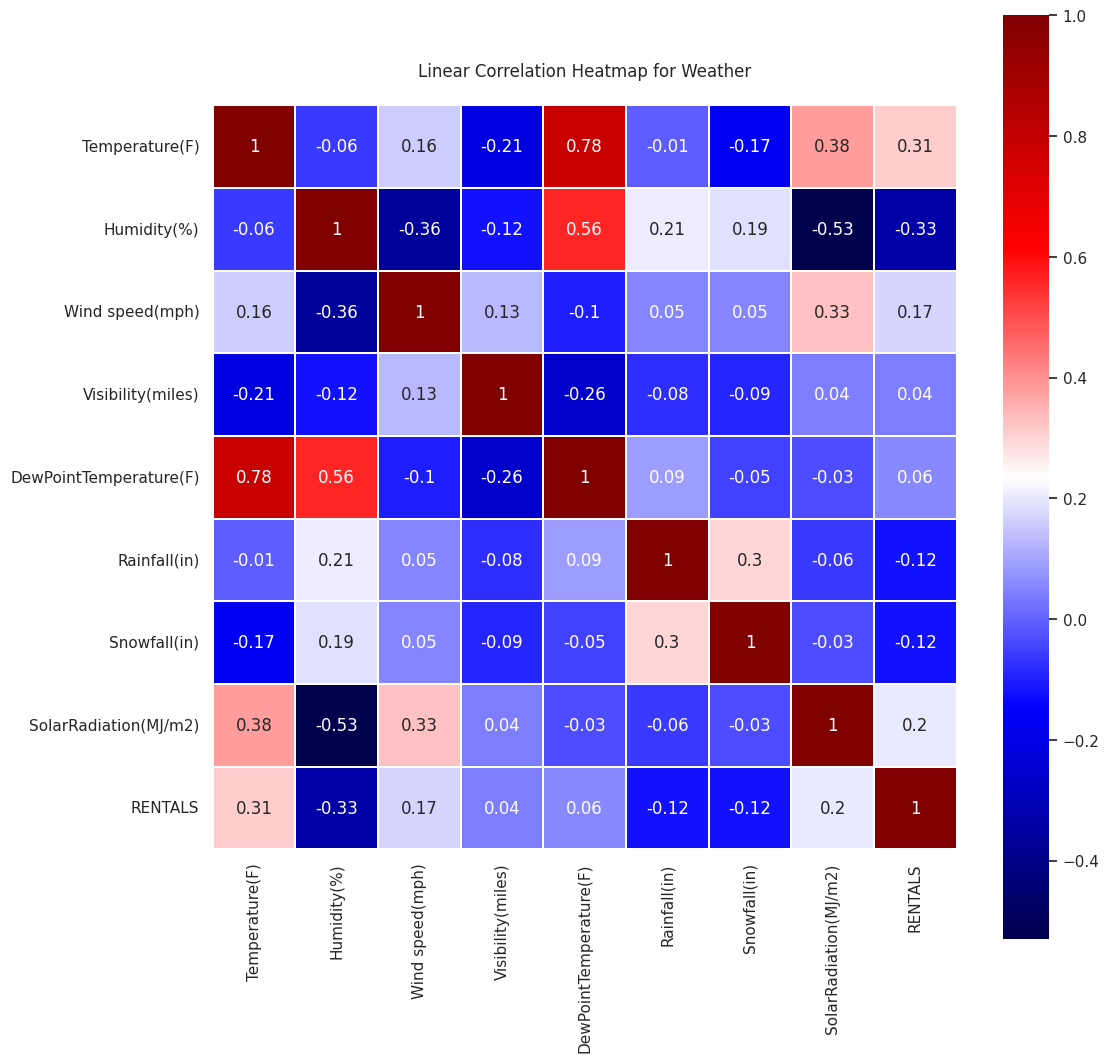

In [109]:
##### Correlation Graphic
# specifying plot size (making it bigger)
fig, ax = plt.subplots( figsize = (12 , 12) )

bikes_corr = bikesRB.iloc[:,1:].corr(method = "pearson", numeric_only=True).round(decimals = 2)


# developing a heatmap to better assess the correlations
sns.heatmap(data       = bikes_corr, # the correlation matrix
            cmap       = 'seismic'   , # changing to MEDIUM colors
            square     = True         , # tightening the layout
            annot      = True         , # should there be numbers in the heatmap
            linecolor  = 'white'      , # lines between boxes
            linewidths = 0.2          ) # how thick should the lines be?


# title and displaying the plot
plt.title(label = """
Linear Correlation Heatmap for Weather
""")

# visualizing the data
plt.show(block = True)

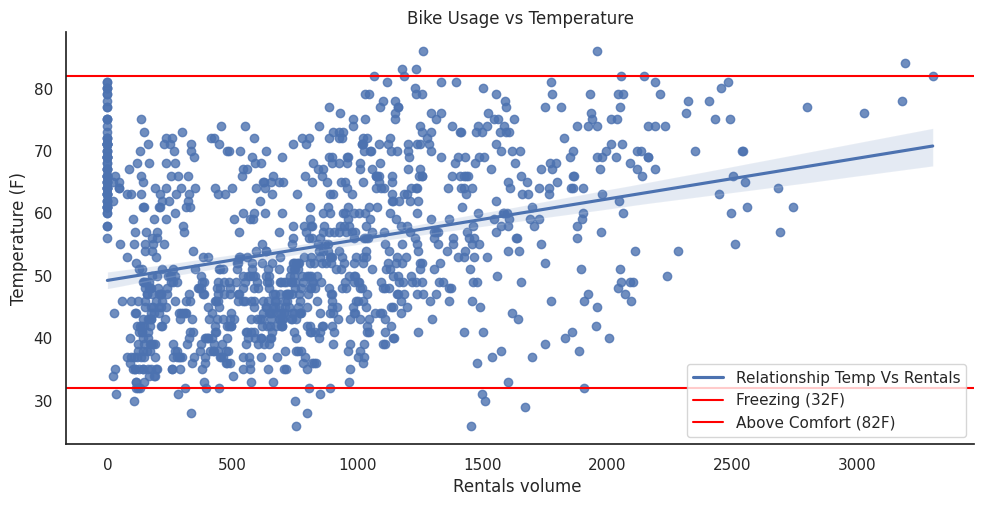

In [110]:
sns.lmplot(x          = 'RENTALS' , # x-axis feature
           y          = 'Temperature(F)' , # y-axis feature
           hue        = None    , # categorical data for subsets
           scatter    = True    , # renders a scatter plot
           fit_reg    = True   , # renders a regression line
           aspect     = 2       , # aspect ratio for plot
           data       = bikesRB, # DataFrame where features exist
           line_kws   = {'label': 'Relationship Temp Vs Rentals'}) # Label for the trendline

plt.axhline(32, color = "red", label = "Freezing (32F)")
plt.axhline(82, color = "red", label = "Above Comfort (82F)")

# formatting and displaying the plot
plt.title       (label  = 'Bike Usage vs Temperature')
plt.xlabel      (xlabel = 'Rentals volume '          )
plt.ylabel      (ylabel = 'Temperature (F)'          )
plt.legend      ()
plt.show        (block  = True                       )

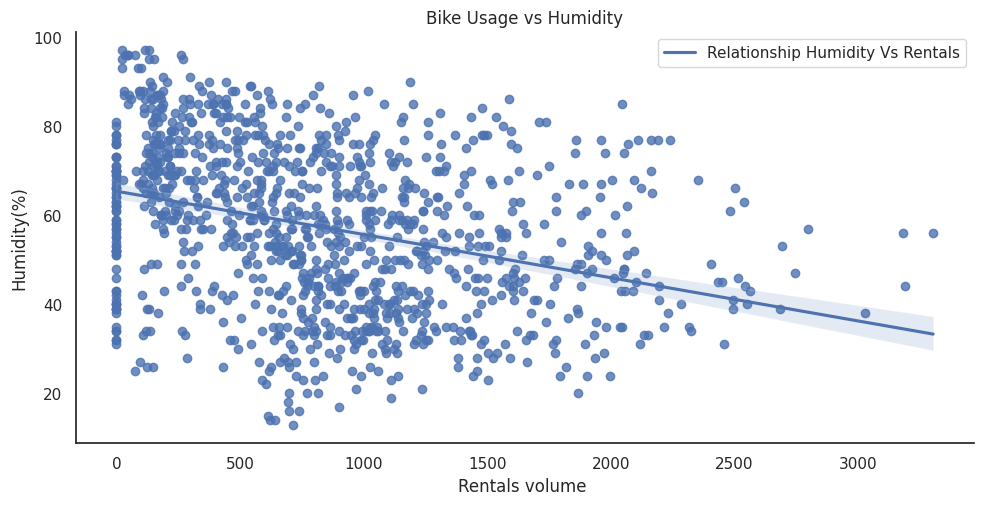

In [113]:
##### THIS IS TO UNDERSTAND THE RELATIONSHIP BETWEEN HUMIDITY AND RENTALS ############
#Sizing the graphic
sns.set_style("white")

sns.lmplot(x          = 'RENTALS' , # x-axis feature
           y          = 'Humidity(%)' , # y-axis feature
           hue        = None    , # categorical data for subsets
           scatter    = True    , # renders a scatter plot
           fit_reg    = True   , # renders a regression line
           aspect     = 2       , # aspect ratio for plot
           data       = bikesRB, # DataFrame where features exist
           line_kws   = {'label': 'Relationship Humidity Vs Rentals'})

# formatting and displaying the plot
plt.title       (label  = 'Bike Usage vs Humidity')
plt.xlabel      (xlabel = 'Rentals volume '       )
plt.ylabel      (ylabel = 'Humidity(%)'           )
plt.legend      ()
plt.show        (block  = True                    )

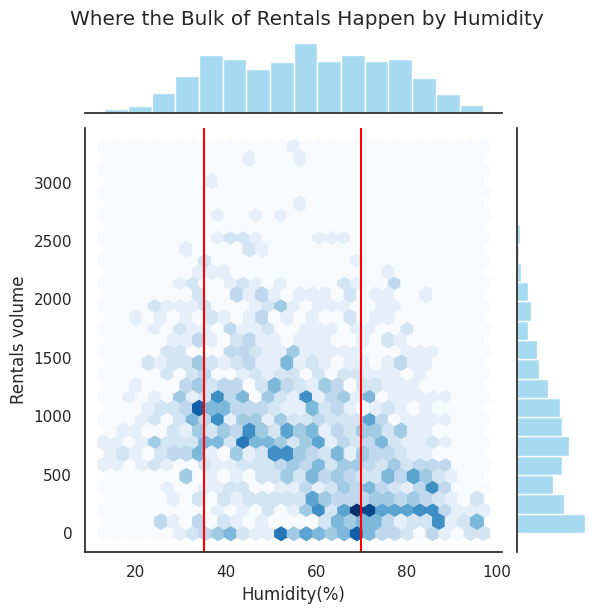

In [111]:

sns.set_style("white")

# Jointplot with customized hex sizes
sns.jointplot(data = bikesRB,
              x    ='Humidity(%)',
              y    ='RENTALS',
              kind ='hex',
              cmap ='Blues',
              joint_kws=dict(gridsize=30), # <--- HEXAGONS SMALLER
              marginal_kws=dict(color="skyblue", edgecolor="white", linewidth=1)
)

plt.axvline(35, color = "red", label = "Minimum to Comfort")
plt.axvline(70, color = "red", label = "Ideal to Comfort")


plt.suptitle('Where the Bulk of Rentals Happen by Humidity', y=1.02)
plt.xlabel      (xlabel = 'Humidity(%)'       )
plt.ylabel      (ylabel = 'Rentals volume'    )
plt.show()